In [1]:
!pip install torch torchvision pillow efficientnet-pytorch scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import subprocess

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms
from efficientnet_pytorch import EfficientNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)


✅ Using device: cuda


In [ ]:
# ============================================================================
# AUTO-DETECT PATHS & MODEL (works with friend's laptop paths or yours)
# ============================================================================

print("🔍 Searching for model checkpoint and data paths...\n")

# 1. Search for checkpoint in common locations
CHECKPOINT_LOCATIONS = [
    "checkpoints/efficientnet_b0_best.pth",
    "../models/efficientnet_b0_best.pth",
    "models/efficientnet_b0_best.pth",
    "C:/Users/sreeh/Downloads/efficientnet_b0_best.pth",
    "C:/Users/sreeh/OneDrive/Documents/Desktop/AgroChat/models/efficientnet_b0_best.pth",
]

CHECKPOINT_PATH = None
for path in CHECKPOINT_LOCATIONS:
    try:
        if os.path.exists(path):
            CHECKPOINT_PATH = path
            print(f"✅ Found checkpoint: {path}")
            break
    except:
        pass

if not CHECKPOINT_PATH:
    print("⚠️  Checkpoint not found in common locations.")
    print("   Tip: Place the .pth file in 'models/' or update CHECKPOINT_PATH below.")
    CHECKPOINT_PATH = "models/efficientnet_b0_best.pth"
    print(f"   Using fallback path: {CHECKPOINT_PATH}\n")

# 2. Detect available offline LLM
def detect_available_llm():
    """Check which offline LLM is available and return mode."""
    # Try Ollama
    try:
        result = subprocess.run(["ollama", "--version"], capture_output=True, timeout=2, text=True)
        if result.returncode == 0:
            print("✅ Ollama detected. Will use: ollama run llama3.2:1b (or similar)")
            return "ollama"
    except Exception:
        pass
    
    # Check for llama-cpp-python
    try:
        from llama_cpp import Llama
        print("✅ llama-cpp-python available. Can use local ggml models.")
        return "llama_cpp"
    except ImportError:
        pass
    
    # Fallback: stub (for testing without LLM)
    print("⚠️  No offline LLM runtime found (Ollama or llama-cpp-python).")
    print("   → Install Ollama (ollama.ai) OR run: pip install llama-cpp-python")
    print("   → For now, LLM will return STUB responses (testing mode)\n")
    return "stub"

LLM_TYPE = detect_available_llm()
print(f"🤖 LLM Mode: {LLM_TYPE.upper()}\n")


In [3]:
DISEASE_KNOWLEDGE = """
Pepper Bell Bacterial Spot:
- Symptoms: Small dark water-soaked spots on leaves and fruits, yellow halos
- Cause: Xanthomonas bacteria
- Organic Control: Neem oil, copper spray
- Chemical Control: Copper fungicide
- Prevention: Disease-free seeds, crop rotation

Pepper Bell Healthy:
- Condition: Normal growth, no infection
- Prevention: Proper irrigation, balanced fertilizer

Potato Early Blight:
- Symptoms: Brown concentric rings on lower leaves
- Cause: Alternaria solani
- Organic Control: Neem oil
- Chemical Control: Mancozeb
- Prevention: Crop rotation, avoid overhead irrigation

Potato Healthy:
- Condition: Normal leaf color, strong stems
- Prevention: Balanced nutrition, disease-free seed tubers

Potato Late Blight:
- Symptoms: Dark water-soaked lesions, white mold on leaf undersides, tuber rot
- Cause: Phytophthora infestans
- Organic Control: Neem oil, copper oxychloride
- Chemical Control: Mancozeb, Metalaxyl
- Prevention: Crop rotation, remove infected plant debris, avoid water stagnation

Tomato Bacterial Spot:
- Symptoms: Dark leaf spots, small scabby spots on fruit
- Cause: Xanthomonas bacteria
- Organic Control: Neem oil, copper sprays
- Chemical Control: Copper fungicides
- Prevention: Use certified seeds, avoid overhead irrigation

Tomato Early Blight:
- Symptoms: Brown leaf rings with concentric target-like spots
- Cause: Alternaria solani
- Organic Control: Neem oil, compost teas
- Chemical Control: Mancozeb, chlorothalonil
- Prevention: Crop rotation, remove infected leaves

Tomato Healthy:
- Condition: Healthy green leaves, no visible spots, good vigor
- Prevention: Proper irrigation, balanced fertilizer, good spacing

Tomato Late Blight:
- Symptoms: Black greasy lesions on leaves and stems, white mold under leaves
- Cause: Phytophthora infestans
- Organic Control: Neem oil, copper oxychloride
- Chemical Control: Mancozeb, Metalaxyl
- Prevention: Avoid water stagnation, remove infected plants

Tomato Leaf Mold:
- Symptoms: Yellow patches on upper leaf surface, olive-green mold on underside
- Cause: Passalora fulva (fungus)
- Organic Control: Good ventilation, pruning, neem oil
- Chemical Control: Fungicides containing copper or chlorothalonil
- Prevention: Avoid overcrowding, reduce humidity in greenhouse

Tomato Septoria Leaf Spot:
- Symptoms: Small circular brown spots with light centers and dark borders
- Cause: Septoria lycopersici fungus
- Organic Control: Neem oil, remove infected leaves
- Chemical Control: Protective fungicides (e.g., copper-based)
- Prevention: Crop rotation, avoid overhead watering

Tomato Spider Mites:
- Symptoms: Yellow speckling on leaves, fine webbing, leaf bronzing
- Cause: Spider mites (pest)
- Organic Control: Neem oil, insecticidal soap, water spray
- Prevention: Maintain plant health, avoid very dry dusty conditions

Tomato Target Spot:
- Symptoms: Circular dark spots with concentric rings, often on lower leaves
- Cause: Corynespora cassiicola fungus
- Organic Control: Neem oil, sanitation
- Chemical Control: Fungicidal sprays where permitted
- Prevention: Crop rotation, good airflow, remove infected debris

Tomato Mosaic Virus:
- Symptoms: Mottled light and dark green leaves, leaf distortion
- Cause: Tomato mosaic virus
- Organic Control: Remove infected plants, sanitize tools
- Prevention: Use virus-free seeds, avoid tobacco use near plants

Tomato Yellow Leaf Curl Virus:
- Symptoms: Curled yellow leaves, stunted plants
- Cause: Virus transmitted by whiteflies
- Organic Control: Yellow sticky traps, neem oil for whitefly control
- Prevention: Resistant varieties, whitefly management, remove infected plants
"""

# Map your CNN class names to the titles used in DISEASE_KNOWLEDGE
CLASS_TO_TITLE = {
    "Pepper__bell___Bacterial_spot": "Pepper Bell Bacterial Spot",
    "Pepper__bell___healthy": "Pepper Bell Healthy",
    "Potato___Early_blight": "Potato Early Blight",
    "Potato___Late_blight": "Potato Late Blight",
    "Potato___healthy": "Potato Healthy",
    "Tomato_Bacterial_spot": "Tomato Bacterial Spot",
    "Tomato_Early_blight": "Tomato Early Blight",
    "Tomato_Late_blight": "Tomato Late Blight",
    "Tomato_Leaf_Mold": "Tomato Leaf Mold",
    "Tomato_Septoria_leaf_spot": "Tomato Septoria Leaf Spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite": "Tomato Spider Mites",
    "Tomato__Target_Spot": "Tomato Target Spot",
    "Tomato__Tomato_mosaic_virus": "Tomato Mosaic Virus",
    "Tomato__Tomato_YellowLeaf__Curl_Virus": "Tomato Yellow Leaf Curl Virus",
    "Tomato_healthy": "Tomato Healthy",
}


In [ ]:
def ask_offline_llm(prompt: str) -> str:
    """
    Flexible offline LLM caller. Tries Ollama, then llama_cpp, then stub.
    Works with any offline model setup on your system.
    """
    global LLM_TYPE
    
    # ===== OLLAMA MODE =====
    if LLM_TYPE == "ollama":
        try:
            process = subprocess.Popen(
                ["ollama", "run", "llama3.2:1b"],
                stdin=subprocess.PIPE,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                encoding="utf-8",
                errors="ignore",
            )
            output, error = process.communicate(prompt, timeout=30)
            if output and output.strip():
                return output.strip()
            else:
                return "⚠️ Ollama returned no output. Check if model is pulled: ollama pull llama3.2:1b"
        except subprocess.TimeoutExpired:
            return "⚠️ Ollama timeout. Try again or check if service is running."
        except Exception as e:
            print(f"❌ Ollama call failed: {e}. Falling back to stub mode.")
            LLM_TYPE = "stub"
    
    # ===== LLAMA_CPP MODE =====
    if LLM_TYPE == "llama_cpp":
        try:
            from llama_cpp import Llama
            import os as os_module
            model_path = os_module.getenv("LLAMA_MODEL_PATH")
            if not model_path:
                return "⚠️ LLAMA_MODEL_PATH env var not set. Set it to your ggml model file path."
            if not os_module.path.exists(model_path):
                return f"⚠️ Model file not found at {model_path}"
            
            llm = Llama(model_path=model_path, n_gpu_layers=-1)
            resp = llm.create(prompt=prompt, max_tokens=512, temperature=0.1)
            choices = resp.get("choices", [])
            if choices:
                return choices[0].get("text", "").strip()
            return "⚠️ llama_cpp returned empty response."
        except Exception as e:
            print(f"❌ llama_cpp call failed: {e}. Falling back to stub mode.")
            LLM_TYPE = "stub"
    
    # ===== STUB MODE (testing/fallback) =====
    if LLM_TYPE == "stub":
        stub_response = f"""
⚠️  STUB LLM RESPONSE (Testing Mode)
(No actual LLM running. Install Ollama or llama-cpp-python to enable real responses.)

Question: {prompt[:100]}...
Answer: This is a placeholder response. To enable real LLM responses:
  1. Install Ollama from ollama.ai and run: ollama pull llama3.2:1b
  2. Or use llama-cpp-python: pip install llama-cpp-python
  3. Then rerun this notebook.
"""
        return stub_response.strip()
    
    return "❌ Unknown LLM mode."


class OfflineAgriculturalRAG:
    def __init__(self, knowledge_base: str, class_to_title: dict):
        self.knowledge_base = knowledge_base.strip()
        self.class_to_title = class_to_title
        print("✅ Offline Knowledge Base Loaded")

    def _get_block_for_class(self, primary_disease: str) -> str:
        """
        Match CNN class name to the corresponding block in DISEASE_KNOWLEDGE.
        If not found, return the entire knowledge base as a fallback.
        """
        title = self.class_to_title.get(primary_disease)
        if not title:
            return self.knowledge_base   # ✅ safe fallback

        blocks = self.knowledge_base.split("\n\n")
        for block in blocks:
            first_line = block.splitlines()[0].rstrip(":").strip()
            if first_line.lower() == title.lower():
                return block

        return self.knowledge_base   # ✅ safe fallback

    # ✅ ✅ ✅ STRICT MODE QUERY (NO HALLUCINATIONS)
    def query(self, user_question: str, prediction: dict) -> str:
        primary_disease = prediction["disease"]
        filtered_knowledge = self._get_block_for_class(primary_disease)

        prompt = f"""
You are a STRICT INFORMATION EXTRACTION SYSTEM.

YOU MUST FOLLOW THESE RULES:
1. You MUST copy answers ONLY from the RAG knowledge below.
2. You MUST NOT rephrase, explain, or add even a single new sentence.
3. You MUST NOT add steps, inspections, monitoring, or safety advice unless it exists in RAG.
4. If something is missing, output exactly: Not specified in knowledge
5. You MUST ignore all general training knowledge.

-------------------------------------
CNN PREDICTION:
Disease Name: {primary_disease}
Confidence: {prediction['confidence'] * 100:.2f} %

-------------------------------------
USER QUESTION:
{user_question}

-------------------------------------
RAG KNOWLEDGE (ONLY SOURCE):
{filtered_knowledge}

-------------------------------------
RESPONSE FORMAT (STRICT):

Confirmed Disease:
Symptoms:
Cause:
Organic Control:
Prevention:

-------------------------------------
FINAL ANSWER:
"""

        return ask_offline_llm(prompt)


# ✅ Create the RAG system instance (same as before)
rag = OfflineAgriculturalRAG(DISEASE_KNOWLEDGE, CLASS_TO_TITLE)


✅ Offline Knowledge Base Loaded


In [5]:
# Path to your trained EfficientNet checkpoint
CHECKPOINT_PATH = "checkpoints/efficientnet_b0_best.pth"  # change if needed

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# This should be the same list you saw printed out before
class_names = checkpoint["classes"]

model = EfficientNet.from_pretrained(
    "efficientnet-b0",
    num_classes=len(class_names)
)

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()

print("✅ CNN Model Loaded")
print("✅ Classes:", class_names)

# Image transform used at training / inference time
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


Loaded pretrained weights for efficientnet-b0
✅ CNN Model Loaded
✅ Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
class IntegratedPlantDiseaseSystem:
    def __init__(self, model, class_names, rag_system, device, transform):
        self.model = model
        self.class_names = class_names
        self.rag = rag_system
        self.device = device
        self.transform = transform

    def predict_disease(self, image_path: str) -> dict:
        # Load and preprocess image
        img = Image.open(image_path).convert("RGB")
        img = self.transform(img).unsqueeze(0).to(self.device)

        # CNN forward pass
        with torch.no_grad():
            logits = self.model(img)
            probs = F.softmax(logits, dim=1)[0]

        conf, idx = torch.max(probs, 0)

        return {
            "disease": self.class_names[idx.item()],
            "confidence": float(conf),
        }

    def diagnose_and_advise(self, image_path: str, user_question: str):
        """
        Runs CNN prediction + RAG explanation.
        Returns (prediction_dict, text_answer)
        """
        prediction = self.predict_disease(image_path)
        answer = self.rag.query(
            user_question=user_question,
            prediction=prediction,
        )
        return prediction, answer


# Build the integrated system
system = IntegratedPlantDiseaseSystem(
    model=model,
    class_names=class_names,
    rag_system=rag,
    device=device,
    transform=transform,
)
print("✅ Integrated system ready")


✅ Integrated system ready


In [7]:
# Change this to any test image you want
test_image_path = r"K:\cnndisease\00b1f292-23dd-44d4-aad3-c1ffb6a6ad5a___RS_LB 4479.JPG"
user_question = "How can I treat this organically?"

prediction, answer = system.diagnose_and_advise(
    image_path=test_image_path,
    user_question=user_question,
)

print("\n🦠 Disease:", prediction["disease"])
print("Confidence:", round(prediction["confidence"] * 100, 2), "%")
print("\n💊 Treatment:\n", answer)



🦠 Disease: Potato___Late_blight
Confidence: 91.2 %

💊 Treatment:
 Potato Late Blight:
Symptoms: Dark water-soaked lesions, white mold on leaf undersides, tuber rot
Cause: Phytophthora infestans
Organic Control: Neem oil, copper oxychloride
Prevention: Crop rotation, remove infected plant debris, avoid water stagnation


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import json
import numpy as np
import torch

TEST_DIR = r"K:\plant villagee\PlantVillage"

# ✅ Ensure model on correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# ✅ Transforms (same as training)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        _, preds = torch.max(out, 1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        if len(y_true) % 500 == 0:
            print("Processed:", len(y_true), "images")

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

accuracy = report["accuracy"]
macro_f1 = report["macro avg"]["f1-score"]

readiness = {
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "status": "✅ EXCELLENT" if accuracy > 0.95 else "⚠️ TRAIN MORE"
}

with open("cnn_readiness_report.json", "w") as f:
    json.dump(readiness, f, indent=4)

print("\n✅ CNN Readiness:", readiness)


Processed: 4000 images
Processed: 8000 images
Processed: 12000 images
Processed: 16000 images
Processed: 20000 images

✅ CNN Readiness: {'accuracy': 0.9987886423103014, 'macro_f1': 0.9990768907160664, 'status': '✅ EXCELLENT'}


In [9]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, log_loss, accuracy_score

# ✅ Collect full probability distributions
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

print("✅ Total Samples Processed:", len(all_labels))

# -------------------------------------------------
# ✅ MEAN RECIPROCAL RANK (MRR)
# -------------------------------------------------

def mean_reciprocal_rank(probs, labels):
    ranks = []
    for i in range(len(labels)):
        sorted_indices = np.argsort(-probs[i])
        rank = np.where(sorted_indices == labels[i])[0][0] + 1
        ranks.append(1.0 / rank)
    return np.mean(ranks)

mrr_score = mean_reciprocal_rank(all_probs, all_labels)

# -------------------------------------------------
# ✅ TOP-K ACCURACY
# -------------------------------------------------

def top_k_accuracy(probs, labels, k=3):
    top_k_preds = np.argsort(-probs, axis=1)[:, :k]
    correct = sum(labels[i] in top_k_preds[i] for i in range(len(labels)))
    return correct / len(labels)

top1_acc = accuracy_score(all_labels, np.argmax(all_probs, axis=1))
top3_acc = top_k_accuracy(all_probs, all_labels, k=3)

# -------------------------------------------------
# ✅ PRECISION / RECALL / F1
# -------------------------------------------------

macro_precision = precision_score(all_labels, y_pred, average="macro")
macro_recall = recall_score(all_labels, y_pred, average="macro")
macro_f1 = f1_score(all_labels, y_pred, average="macro")

micro_precision = precision_score(all_labels, y_pred, average="micro")
micro_recall = recall_score(all_labels, y_pred, average="micro")
micro_f1 = f1_score(all_labels, y_pred, average="micro")

# -------------------------------------------------
# ✅ LOG LOSS
# -------------------------------------------------

loss = log_loss(all_labels, all_probs)

# -------------------------------------------------
# ✅ FINAL METRICS REPORT
# -------------------------------------------------

print("\n==============================")
print("✅ ADVANCED CNN METRICS REPORT")
print("==============================")

print(f"✅ Top-1 Accuracy  : {top1_acc * 100:.2f} %")
print(f"✅ Top-3 Accuracy  : {top3_acc * 100:.2f} %")
print(f"✅ Mean Reciprocal Rank (MRR): {mrr_score:.4f}")

print("\n📊 Macro Metrics:")
print(f"   Precision: {macro_precision:.4f}")
print(f"   Recall   : {macro_recall:.4f}")
print(f"   F1-score : {macro_f1:.4f}")

print("\n📊 Micro Metrics:")
print(f"   Precision: {micro_precision:.4f}")
print(f"   Recall   : {micro_recall:.4f}")
print(f"   F1-score : {micro_f1:.4f}")

print(f"\n📉 Log Loss: {loss:.6f}")


✅ Total Samples Processed: 20638

✅ ADVANCED CNN METRICS REPORT
✅ Top-1 Accuracy  : 99.88 %
✅ Top-3 Accuracy  : 100.00 %
✅ Mean Reciprocal Rank (MRR): 0.9994

📊 Macro Metrics:
   Precision: 0.9989
   Recall   : 0.9993
   F1-score : 0.9991

📊 Micro Metrics:
   Precision: 0.9988
   Recall   : 0.9988
   F1-score : 0.9988

📉 Log Loss: 0.167019


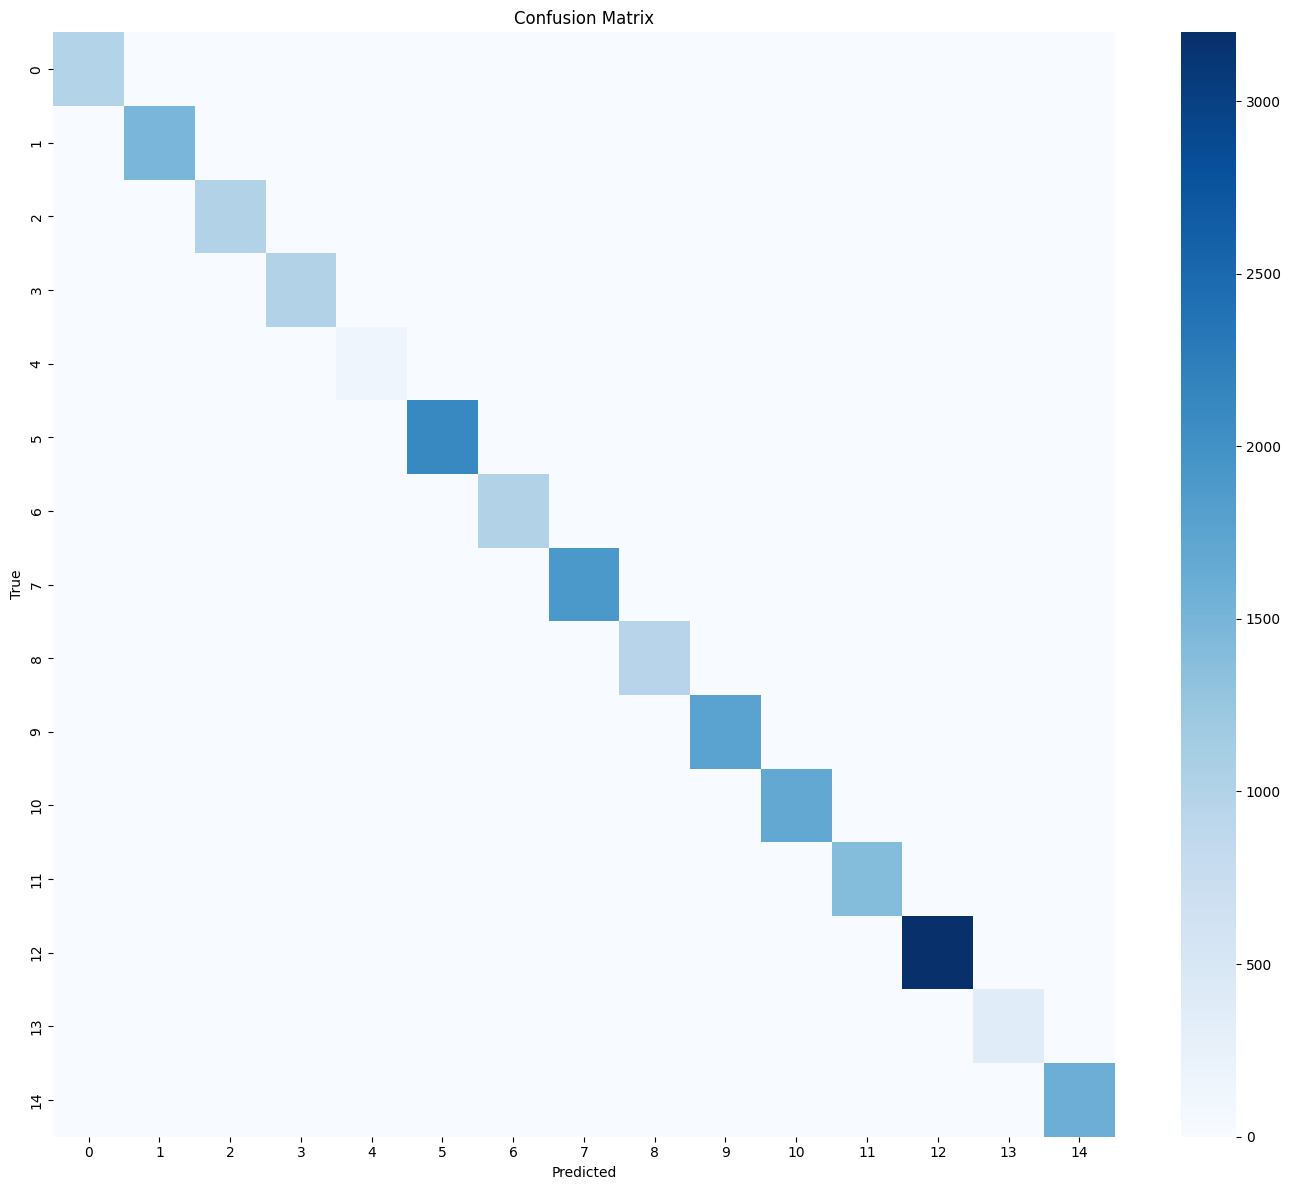

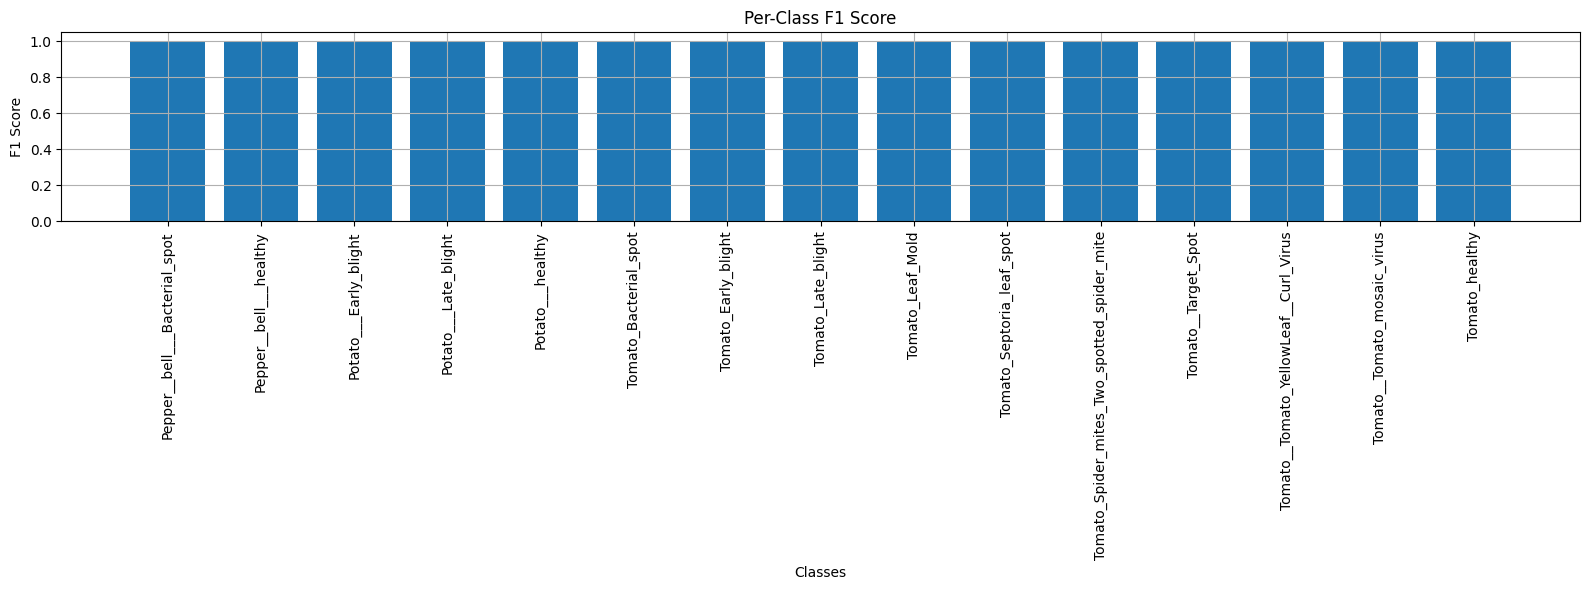

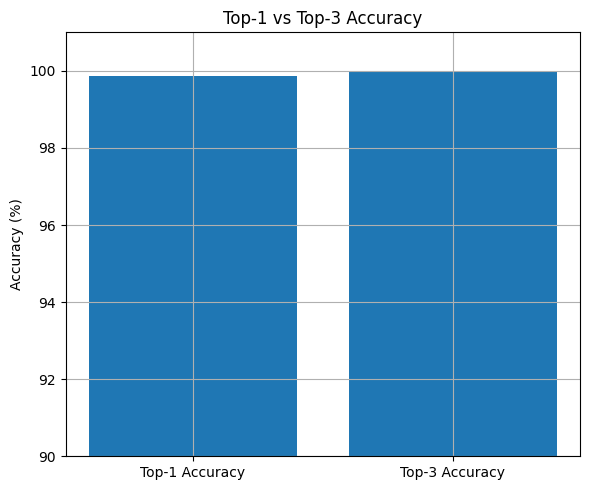

✅ All CNN Performance Graphs Generated Successfully!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# -------------------------------------------------
# ✅ CONFUSION MATRIX
# -------------------------------------------------

cm = confusion_matrix(all_labels, np.argmax(all_probs, axis=1))

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# ✅ PER-CLASS F1 SCORE
# -------------------------------------------------

class_f1 = f1_score(all_labels, y_pred, average=None)

plt.figure(figsize=(16, 6))
plt.bar(range(len(class_f1)), class_f1)
plt.xticks(range(len(class_f1)), class_names, rotation=90)
plt.title("Per-Class F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Classes")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# ✅ TOP-1 vs TOP-3 ACCURACY
# -------------------------------------------------

acc_values = [top1_acc * 100, top3_acc * 100]
acc_labels = ["Top-1 Accuracy", "Top-3 Accuracy"]

plt.figure(figsize=(6, 5))
plt.bar(acc_labels, acc_values)
plt.title("Top-1 vs Top-3 Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 101)
plt.grid(True)
plt.tight_layout()
plt.show()

print("✅ All CNN Performance Graphs Generated Successfully!")


In [11]:
# ===========================================
# ✅ RAG RETRIEVAL ACCURACY TEST
# ===========================================

correct = 0
total = 0

for cnn_class in class_names:
    expected_title = CLASS_TO_TITLE.get(cnn_class)
    retrieved_block = rag._get_block_for_class(cnn_class)

    if expected_title is None:
        continue  # Skip if mapping missing

    retrieved_title = retrieved_block.splitlines()[0].replace(":", "").strip()

    if retrieved_title.lower() == expected_title.lower():
        correct += 1

    total += 1

rag_accuracy = correct / total

print("✅ RAG Retrieval Accuracy:", round(rag_accuracy * 100, 2), "%")
print("✅ Correct Matches:", correct, "/", total)


✅ RAG Retrieval Accuracy: 100.0 %
✅ Correct Matches: 15 / 15


In [12]:
# ===========================================
# ✅ LLM FAITHFULNESS / HALLUCINATION CHECK
# ===========================================

def llm_faithfulness_score(answer, rag_block):
    rag_words = set(rag_block.lower().split())
    ans_words = set(answer.lower().split())

    overlap = len(rag_words & ans_words)
    score = overlap / len(rag_words)

    return score


# Test using last inference
rag_block = rag._get_block_for_class(prediction["disease"])
faithfulness = llm_faithfulness_score(answer, rag_block)

print("✅ LLM Faithfulness Score:", round(faithfulness * 100, 2), "%")


✅ LLM Faithfulness Score: 89.19 %
